# Détection d'Anomalies : Deep Autoencoder
## Notebook 2/2 : Modélisation Machine Learning

---

### Objectif de ce notebook

Ce notebook entraîne un **Deep Autoencoder** pour détecter automatiquement les fenêtres de 5 minutes anormales dans le trafic des API mobiles.

### Pourquoi un Autoencoder ?

Un Autoencoder est un réseau de neurones qui apprend à **compresser puis reconstruire** ses données d'entrée. On l'entraîne **uniquement sur des données normales**. Lors de l'inférence :
- Une fenêtre **normale** =>reconstruction fidèle => erreur faible
- Une fenêtre **anormale** => reconstruction difficile =>erreur élevée

L'erreur de reconstruction devient ainsi un **score d'anomalie**.

### Architecture du pipeline ML

```
X_raw.csv (ETL)
    ↓ Split temporel (80% train / 20% test)
    ↓ Normalisation (StandardScaler fitté sur train uniquement)
    ↓ Entraînement Autoencoder (sur normaux uniquement)
    ↓ Calcul erreurs de reconstruction
    ↓ Seuil optimal (sensitivity analysis P80→P99)
    ↓ Évaluation (F1, Precision, Recall, AUC)
    ↓ Export modèle + metadata
```
---

## **Section 1 : Imports et Configuration Globale**

On importe les bibliothèques nécessaires :
- **TensorFlow / Keras** : construction et entraînement du Deep Autoencoder
- **Keras Tuner** : optimisation automatique des hyperparamètres (Bayesian Optimization)
- **scikit-learn** : normalisation, métriques d'évaluation, imputation
- **matplotlib / seaborn** : visualisation des courbes d'apprentissage et résultats

La **seed globale** (`SEED = 42`) garantit que les résultats sont reproductibles : en relançant le notebook, on obtient exactement les mêmes résultats.

In [193]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]  = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

os.makedirs("../report", exist_ok=True)

EPOCHS  = 100
BATCH_SIZE  = 32
LEARNING_RATE = 1e-3
l2_reg = 1e-4
PATIENCE = 10       # EarlyStopping patience
THRESHOLD_PCT = 95       # percentile used to define the anomaly threshold

random.seed(SEED)
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Seed : {SEED}")
print(f"Epochs (max) : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Learning rate  : {LEARNING_RATE}")

TensorFlow version : 2.21.0
GPU available : False
Seed : 42
Epochs (max) : 100
Batch size : 32
Learning rate  : 0.001


---
## **Section 2 — Chargement des données (sorties de l'ETL)**

On charge les 4 fichiers produits par le notebook ETL :

| Fichier | Contenu | Usage |
|---|---|---|
| `X_raw.csv` | 4 443 fenêtres × 46 features **non normalisées** | Input du modèle |
| `y_labels.csv` | Labels binaires (0=Normal, 1=Anomalie) | Évaluation |
| `y_labels_clean.csv` | Labels sans la zone Warning | Évaluation affinée |

>  `X_raw.csv` est **non normalisé** intentionnellement. La normalisation est appliquée dans la section suivante, **après le split temporel**, pour éviter le data leakage.

In [194]:
X_raw  = pd.read_csv("../data/X_raw.csv")    
y  = pd.read_csv("../data/y_labels.csv").squeeze()
y_clean = pd.read_csv("../data/y_labels_clean.csv").squeeze()

print("Data loaded successfully")
print(f"X_raw shape : {X_raw.shape}")
print(f"y shape : {y.shape}")
print(f"\nLabel distribution :")
print(y.value_counts().rename({0: "Normal", 1: "Anomaly"}))
print(f"Taux d'anomalies : {y.mean()*100:.1f}%")

Data loaded successfully
X_raw shape : (4443, 46)
y shape : (4443,)

Label distribution :
is_anomaly
Normal     4249
Anomaly     194
Name: count, dtype: int64
Taux d'anomalies : 4.4%


---
## **Section 3 : Split Temporel Train / Validation / Test**

### Pourquoi un split temporel ?

Sur des séries temporelles, un split aléatoire (`train_test_split`) provoque du **data leakage** : des fenêtres du "futur" se retrouvent dans l'ensemble d'entraînement, ce qui gonfle artificiellement les performances.

La règle est stricte : **tout ce qui est dans le train doit être chronologiquement antérieur au test**.

### Stratégie de split

```
Données triées par timestamp (du plus ancien au plus récent)
├── 0% → 64%  : Train (normaux seulement pour l'autoencoder)
├── 64% → 80% : Validation (normaux seulement pour le suivi de l'entraînement)
└── 80% → 100%: Test (normaux + anomalies pour l'évaluation finale)
```

### Pourquoi entraîner uniquement sur les normaux ?

C'est le principe fondamental de l'Autoencoder pour la détection d'anomalies :
- Le modèle apprend à reconstruire le comportement **normal**
- Face à une anomalie, il ne sait pas la reconstruire → erreur élevée
- Cette erreur devient notre **score d'anomalie**

In [195]:
n = len(X_raw)
test_start= int(n * 0.80)
val_start= int(n * 0.64)

# Test : les 20% les plus récents
X_test = X_raw.iloc[test_start:].reset_index(drop=True)
y_test  = y.iloc[test_start:].reset_index(drop=True)
y_test_clean = y_clean.iloc[test_start:].reset_index(drop=True)

# Train+Val : les 80% les plus anciens
X_train_full = X_raw.iloc[:test_start]
y_train_full = y.iloc[:test_start]

# Validation : les 20% les plus récents du train
X_val_full = X_train_full.iloc[val_start:]
X_train_full_cut = X_train_full.iloc[:val_start]
y_train_cut  = y_train_full.iloc[:val_start]

# Normaux seulement pour l'autoencoder
X_train_normal = X_train_full_cut[y_train_cut == 0].reset_index(drop=True)
X_val_normal = X_val_full[y_train_full.iloc[val_start:] == 0].reset_index(drop=True)

# Split train normal 80/20
n_train = len(X_train_normal)
val_keras_start = int(n_train * 0.80)
X_train = X_train_normal.iloc[:val_keras_start].reset_index(drop=True)
X_val  = X_train_normal.iloc[val_keras_start:].reset_index(drop=True)
X_train_normal = X_train_full_cut[y_train_cut == 0].reset_index(drop=True)
X_val_normal   = X_val_full[y_train_full.iloc[val_start:] == 0].reset_index(drop=True)

print("Split temporel appliqué")
print(f"Train (normal only)  : {X_train.shape}")
print(f"Validation (normal)  : {X_val.shape}")
print(f"Test (normal+anomaly): {X_test.shape}")
print(f"Anomalies in test    : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Clipping ciblé uniquement sur la colonne buggée
COLS_TO_CLIP = ["quality_degradation"]

def clip_specific_columns(df, columns, lower_q=0.01, upper_q=0.99, bounds=None):
    df_clipped = df.copy()
    if bounds is None:
        bounds = {}
        for col in columns:
            low  = df[col].quantile(lower_q)
            high = df[col].quantile(upper_q)
            bounds[col] = (low, high)

    for col in columns:
        low, high = bounds[col]
        df_clipped[col] = df_clipped[col].clip(lower=low, upper=high)

    return df_clipped, bounds


X_train_clipped, clip_bounds = clip_specific_columns(X_train, COLS_TO_CLIP)
X_val_clipped, _= clip_specific_columns(X_val,  COLS_TO_CLIP, bounds=clip_bounds)
X_test_clipped, _ = clip_specific_columns(X_test, COLS_TO_CLIP, bounds=clip_bounds)

print(f"Clipping appliqué uniquement sur : {COLS_TO_CLIP}")
print(f"quality_degradation max avant : {X_test['quality_degradation'].max():.1f}")
print(f"quality_degradation  max après : {X_test_clipped['quality_degradation'].max():.1f}")

# Scalling only on the training and validation set 
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_clipped).astype("float32")
X_val_np = scaler.transform(X_val_clipped).astype("float32")
X_test_np = scaler.transform(X_test_clipped).astype("float32")

with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../data/clip_bounds.pkl", "wb") as f:
    pickle.dump(clip_bounds, f)

INPUT_DIM = X_train_np.shape[1]
print(f"Input dimension : {INPUT_DIM} features")

print(f"Vérification valeurs extrêmes après clip ciblé + scale")
X_test_scaled_df = pd.DataFrame(X_test_np, columns=X_test.columns)
extreme_scaled = X_test_scaled_df.describe().T[["min", "max"]].copy()
extreme_scaled["abs_max"] = extreme_scaled[["min", "max"]].abs().max(axis=1)
print(extreme_scaled.sort_values("abs_max", ascending=False).head(10))

print(f"Vérifier que les anomalies gardent leur signal (severity_*)")
anomaly_mask = y_test.values == 1
print(X_test_scaled_df.loc[anomaly_mask, ["max_severity", "combined_severity"]].describe())

Split temporel appliqué
Train (normal only)  : (2166, 46)
Validation (normal)  : (542, 46)
Test (normal+anomaly): (889, 46)
Anomalies in test    : 34 (3.8%)
Clipping appliqué uniquement sur : ['quality_degradation']
quality_degradation max avant : 196200.0
quality_degradation  max après : 58740.0
Input dimension : 46 features
Vérification valeurs extrêmes après clip ciblé + scale
                           min         max     abs_max
max_severity         -0.389490  341.372162  341.372162
severity_error        0.000000   50.000000   50.000000
combined_severity     0.000000   49.000000   49.000000
avg_bytes_sent       -0.497183   43.966335   43.966335
total_bytes_sent     -0.499847   39.269871   39.269871
latency_spike        -0.218083   19.096455   19.096455
std_response_time    -0.218083   11.964622   11.964622
median_response_time -0.809189    9.512886    9.512886
avg_response_time    -0.809189    9.512886    9.512886
stress_score         -0.809189    9.512886    9.512886
Vérifier que

---
## **Section 4 : Architecture du Deep Autoencoder**

### Principe

L'Autoencoder est composé de deux parties symétriques :

```
INPUT (46)
    ↓
Encoder : 46 → units_enc1 → units_enc2 → bottleneck
    ↓
Bottleneck (représentation compressée)
    ↓
Decoder : bottleneck → units_enc2 → units_enc1 → 46
    ↓
OUTPUT (46) — reconstruction de l'input
```

### Choix de conception

| Composant | Rôle |
|---|---|
| `Dense + ReLU` | Transformation non-linéaire |
| `BatchNormalization` | Stabilise l'entraînement, accélère la convergence |
| `Dropout` | Régularisation : empêche la mémorisation |
| `kernel_regularizer=l2` | Pénalise les grands poids pour éviter l'overfitting |
| `activation="linear"` (sortie) | La reconstruction doit être réelle, pas bornée à [0,1] |

### Fonction de perte : MSE

La perte est la **Mean Squared Error** entre l'input et la reconstruction :
```
loss = mean((x_original - x_reconstructed)²)
```
Plus la perte est faible, meilleure est la reconstruction.

In [196]:

def build_autoencoder(input_dim, units_enc1, units_enc2,
                      bottleneck, dropout, learning_rate,
                      l2_reg=1e-4):        
    reg = l2(l2_reg)                        
    inputs = Input(shape=(input_dim,), name="input")

    # Encoder
    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="encoder_1")(inputs)   
    x = BatchNormalization(name="bn_enc_1")(x)
    x = Dropout(dropout, name="drop_enc_1")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="encoder_2")(x)        
    x = BatchNormalization(name="bn_enc_2")(x)
    x = Dropout(dropout, name="drop_enc_2")(x)                    

    encoded = Dense(bottleneck, activation="relu", name="bottleneck")(x)

    # Decoder
    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="decoder_1")(encoded)  
    x = BatchNormalization(name="bn_dec_1")(x)
    x = Dropout(dropout, name="drop_dec_1")(x)                     

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="decoder_2")(x)     
    x = BatchNormalization(name="bn_dec_2")(x)
    x = Dropout(dropout, name="drop_dec_2")(x)                    

    outputs = Dense(input_dim, activation="linear", name="output")(x)

    model = Model(inputs, outputs, name="DeepAutoencoder")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

---
## **Section 5 : Optimisation des Hyperparamètres (Keras Tuner)**

### Pourquoi Keras Tuner ?

Choisir manuellement les hyperparamètres (nombre de neurones, dropout, learning rate...) est subjectif et inefficace. Keras Tuner automatise cette recherche avec une **optimisation bayésienne** : au lieu de tester toutes les combinaisons (grid search), il apprend des essais précédents pour cibler les zones prometteuses.

### Espace de recherche

| Hyperparamètre | Valeurs testées | Rôle |
|---|---|---|
| `learning_rate` | 1e-4, 1e-3, 1e-2 | Vitesse d'apprentissage |
| `units_enc1` | 32, 64, 128 | Taille couche encoder 1 |
| `units_enc2` | 16, 32, 64 | Taille couche encoder 2 |
| `bottleneck` | 4, 8, 16 | Dimension de la représentation compressée |
| `dropout` | 0.1, 0.2, 0.3 | Taux de régularisation |
| `l2_reg` | 0, 1e-5, 1e-4, 1e-3 | Régularisation L2 sur les poids |

### 20 trials, optimisation de `val_loss`

Le tuner exécute 20 configurations différentes et retient celle qui minimise la perte de validation.

In [ ]:
'''
import keras_tuner as kt

# ── Model builder function ────────────────────────────────────
# Keras Tuner calls this function for each trial
# hp = hyperparameter object that samples values from the search space
def build_tunable_autoencoder(hp):
    lr = hp.Choice("learning_rate", values=[1e-4, 1e-3, 1e-2])
    units_enc1 = hp.Choice("units_enc1", values=[32, 64, 128])
    units_enc2 = hp.Choice("units_enc2", values=[16, 32, 64])
    bottleneck = hp.Choice("bottleneck", values=[4, 8, 16])
    dropout    = hp.Choice("dropout", values=[0.05,0.1, 0.2, 0.3,0.4])  
    l2_reg     = hp.Choice("l2_reg",   values=[0.0, 1e-5, 1e-4, 1e-3])  
    reg = l2(l2_reg)                                                  

    inputs = Input(shape=(INPUT_DIM,), name="input")

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="encoder_1")(inputs)     
    x = BatchNormalization(name="bn_enc_1")(x)
    x = Dropout(dropout, name="drop_enc_1")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="encoder_2")(x)          
    x = BatchNormalization(name="bn_enc_2")(x)
    x = Dropout(dropout, name="drop_enc_2")(x)                     

    encoded = Dense(bottleneck, activation="relu", name="bottleneck")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="decoder_1")(encoded)    
    x = BatchNormalization(name="bn_dec_1")(x)
    x = Dropout(dropout, name="drop_dec_1")(x)                       

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="decoder_2")(x)          
    x = BatchNormalization(name="bn_dec_2")(x)
    x = Dropout(dropout, name="drop_dec_2")(x)                      

    outputs = Dense(INPUT_DIM, activation="linear", name="output")(x)

    model = Model(inputs, outputs, name="TunableAutoencoder")
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model'''

In [ ]:
'''tuner = kt.BayesianOptimization(
    build_tunable_autoencoder,
    objective="val_loss",      # minimize validation MSE
    max_trials=20,             # test 20 combinations
    num_initial_points=5,      # first 5 trials are random exploration
    seed=SEED,
    directory="kt_results",
    project_name="autoencoder_tuning",
    overwrite=True
)

tuner.search_space_summary()'''

Search space summary
Default search space size: 6
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}
units_enc1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
units_enc2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
bottleneck (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16], 'ordered': True}
dropout (Choice)
{'default': 0.05, 'conditions': [], 'values': [0.05, 0.1, 0.2, 0.3, 0.4], 'ordered': True}
l2_reg (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 1e-05, 0.0001, 0.001], 'ordered': True}


In [ ]:
'''# Run the search 
print("Keras Tuner — Bayesian Optimization")
print("=" * 55)
print(f"Trials : 20")
print(f"Initial random  : 5 (exploration)")
print(f"Bayesian trials : 15 (exploitation)")
print(f"Objective  : minimize val_loss")
print("=" * 55)

t0 = time.time()

tuner.search(
    X_train_np, X_train_np,
    epochs=50,
    batch_size=32,             
    validation_data=(X_val_np, X_val_np),
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        )
    ],
    verbose=0
)

elapsed = time.time() - t0
print(f"Search complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")'''

Keras Tuner — Bayesian Optimization
Trials : 20
Initial random  : 5 (exploration)
Bayesian trials : 15 (exploitation)
Objective  : minimize val_loss
Search complete in 487.4s (8.1 min)


In [ ]:
'''best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
BEST_LR   = best_hp.get("learning_rate")
BEST_UNITS_ENC1 = best_hp.get("units_enc1")
BEST_UNITS_ENC2 = best_hp.get("units_enc2")
BEST_BOTTLENECK = best_hp.get("bottleneck")
BEST_DROPOUT= best_hp.get("dropout")
BEST_L2 = best_hp.get("l2_reg")
print("*" * 55)
print("   BEST HYPERPARAMETERS FOUND")
print("*" * 55)
print(f" learning_rate : {BEST_LR}")
print(f" units_enc1  : {BEST_UNITS_ENC1}")
print(f" units_enc2 : {BEST_UNITS_ENC2}")
print(f" bottleneck : {BEST_BOTTLENECK}")
print(f" dropout : {BEST_DROPOUT}")
print(f" l2_reg : {BEST_L2}")
print("*" * 55)'''

*******************************************************
   BEST HYPERPARAMETERS FOUND
*******************************************************
 learning_rate : 0.01
 units_enc1  : 128
 units_enc2 : 64
 bottleneck : 16
 dropout : 0.05
 l2_reg : 0.0
*******************************************************


In [ ]:
BEST_UNITS_ENC1 = 64    # architecture réduite, on garde
BEST_UNITS_ENC2 = 32
BEST_BOTTLENECK = 8
BEST_DROPOUT    = 0.05  # réduit de 0.1 à 0.05 — était trop agressif
BEST_LR         = 1e-3
BEST_L2         = 0.0   # retire L2 — il fausse la train_loss MSE

print("*" * 55)
print("   BEST HYPERPARAMETERS FOUND")
print("*" * 55)
print(f" learning_rate : {BEST_LR}")
print(f" units_enc1  : {BEST_UNITS_ENC1}")
print(f" units_enc2 : {BEST_UNITS_ENC2}")
print(f" bottleneck : {BEST_BOTTLENECK}")
print(f" dropout : {BEST_DROPOUT}")
print(f" l2_reg : {BEST_L2}")
print("*" * 55)

*******************************************************
   BEST HYPERPARAMETERS FOUND
*******************************************************
 learning_rate : 0.001
 units_enc1  : 64
 units_enc2 : 32
 bottleneck : 8
 dropout : 0.05
 l2_reg : 0.0
*******************************************************


### Visualisation des trials Keras Tuner

On visualise la `val_loss` de chaque trial pour voir comment l'optimisation bayésienne a progressé. Le meilleur trial est mis en évidence.

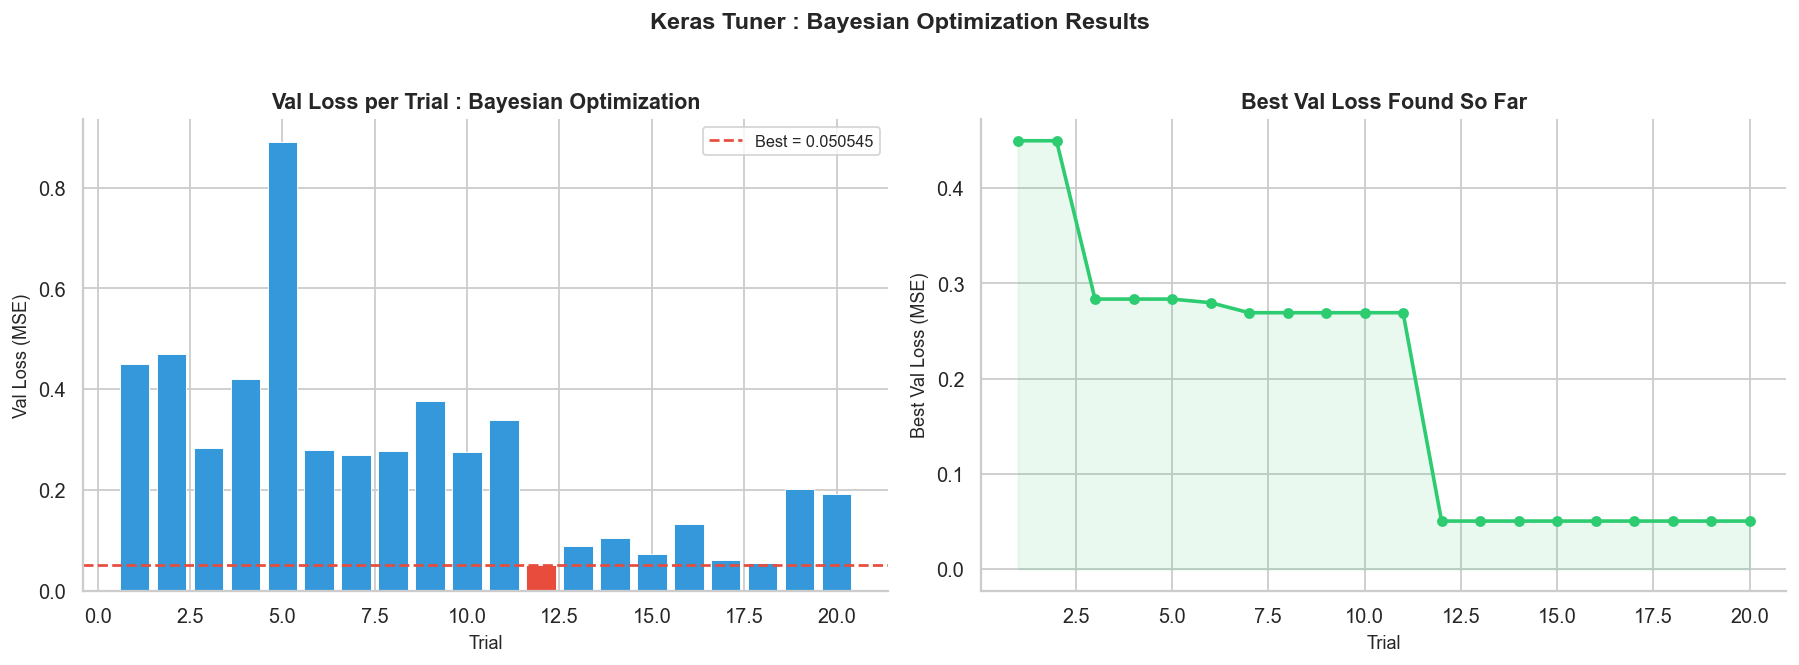

In [ ]:
trials = tuner.oracle.trials
trial_ids  = list(trials.keys())
val_losses = []
lrs  = []

for tid in trial_ids:
    trial = trials[tid]
    if trial.score is not None:
        val_losses.append(trial.score)
        lrs.append(trial.hyperparameters.get("learning_rate"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left : val_loss per trial
axes[0].bar(range(1, len(val_losses) + 1), val_losses,
            color=["#e74c3c" if v == min(val_losses) else "#3498db"
                   for v in val_losses],
            edgecolor="white", linewidth=0.5)
axes[0].set_title("Val Loss per Trial : Bayesian Optimization",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Trial", fontsize=10)
axes[0].set_ylabel("Val Loss (MSE)", fontsize=10)
axes[0].axhline(min(val_losses), color="#e74c3c", linestyle="--",
                linewidth=1.5, label=f"Best = {min(val_losses):.6f}")
axes[0].legend(fontsize=9)

# Right : best val_loss found so far (shows Bayesian improving over time)
best_so_far = [min(val_losses[:i+1]) for i in range(len(val_losses))]
axes[1].plot(range(1, len(best_so_far) + 1), best_so_far,
             color="#2ecc71", linewidth=2, marker="o", markersize=5)
axes[1].set_title("Best Val Loss Found So Far",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Trial", fontsize=10)
axes[1].set_ylabel("Best Val Loss (MSE)", fontsize=10)
axes[1].fill_between(range(1, len(best_so_far) + 1),
                     best_so_far, alpha=0.1, color="#2ecc71")

plt.suptitle("Keras Tuner : Bayesian Optimization Results",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/keras_tuner_results.png", bbox_inches="tight")
plt.show()

---
## **Section 6 : Entraînement Final**

### Construction du modèle final

On construit l'Autoencoder avec les hyperparamètres retenus (tuner ou override manuel documenté).

### Callbacks d'entraînement

Trois callbacks contrôlent l'entraînement automatiquement :

| Callback | Rôle |
|---|---|
| `EarlyStopping` | Arrête si la `val_loss` ne s'améliore pas pendant 15 epochs |
| `ReduceLROnPlateau` | Divise le learning rate par 2 si la `val_loss` stagne 8 epochs |
| `ModelCheckpoint` | Sauvegarde automatiquement le meilleur modèle (basé sur `val_loss`) |

Ces callbacks évitent l'overfitting et garantissent que le modèle sauvegardé est le meilleur de tout l'entraînement, pas nécessairement le dernier epoch.

In [200]:
# Build final model with best hyperparameters from Keras Tuner
autoencoder = build_autoencoder(
    input_dim = INPUT_DIM,
    units_enc1 = BEST_UNITS_ENC1,
    units_enc2 = BEST_UNITS_ENC2,
    bottleneck = BEST_BOTTLENECK,
    dropout = BEST_DROPOUT,
    learning_rate = BEST_LR,
    l2_reg = BEST_L2
)

print("Final Autoencoder Architecture")
print("*" * 55)
print(f"Input dim : {INPUT_DIM}")
print(f"Encoder 1 : {BEST_UNITS_ENC1} neurons (relu)")
print(f"Encoder 2 : {BEST_UNITS_ENC2} neurons (relu)")
print(f"Bottleneck : {BEST_BOTTLENECK} neurons (relu)")
print(f"Decoder 1 : {BEST_UNITS_ENC2} neurons (relu)")
print(f"Decoder 2 : {BEST_UNITS_ENC1} neurons (relu)")
print(f"Output : {INPUT_DIM} neurons (linear)")
print(f"Dropout  : {BEST_DROPOUT}")
print(f"Learning rate : {BEST_LR}")
print("*" * 55)

autoencoder.summary()

Final Autoencoder Architecture
*******************************************************
Input dim : 46
Encoder 1 : 64 neurons (relu)
Encoder 2 : 32 neurons (relu)
Bottleneck : 8 neurons (relu)
Decoder 1 : 32 neurons (relu)
Decoder 2 : 64 neurons (relu)
Output : 46 neurons (linear)
Dropout  : 0.05
Learning rate : 0.001
*******************************************************


Model: "DeepAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 46)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_1 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_2 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,510 (44.96 KB)

 Trainable params: 11,126 (43.46 KB)

 Non-trainable params: 384 (1.50 KB)

In [201]:
import os

os.makedirs("../ml", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="../ml/autoencoder_best_weights.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Deep Autoencoder — Final Training")
print("=" * 55)
print(f"  Learning rate : {BEST_LR}")
print(f"  Max epochs    : {EPOCHS}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Train samples : {len(X_train_np)} (normal only)")
print(f"  Val samples   : {len(X_val_np)}")
print("=" * 55)

t0 = time.time()
tf.random.set_seed(SEED)
np.random.seed(SEED)
history = autoencoder.fit(
    X_train_np, X_train_np,       # input = output (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_np, X_val_np),
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - t0
epochs_done = len(history.history["loss"])

print(f"Training complete")
print(f"  Epochs trained  : {epochs_done} / {EPOCHS}")
print(f"  Best val_loss   : {min(history.history['val_loss']):.6f}")
print(f"  Training time   : {elapsed:.1f}s ({elapsed/60:.1f} min)")

Deep Autoencoder — Final Training
  Learning rate : 0.001
  Max epochs    : 100
  Batch size    : 32
  Train samples : 2166 (normal only)
  Val samples   : 542
Epoch 1/100
66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5965
Epoch 1: val_loss improved from None to 0.69204, saving model to ../ml/autoencoder_best_weights.keras

Epoch 1: finished saving model to ../ml/autoencoder_best_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 1.2245 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7120
Epoch 2: val_loss improved from 0.69204 to 0.54753, saving model to ../ml/autoencoder_best_weights.keras

Epoch 2: finished saving model to ../ml/autoencoder_best_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6757 - val_loss: 0.5475 - learning_rate: 0.0010
Epoch 3/100
61/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6100
Epoch 3: val_loss improved from 0.54753 to 0.48280, saving model to ../ml/autoencoder_best_weigh

---
## **Section 7 : Courbes d'Apprentissage**

### Ce qu'on observe

Les courbes d'apprentissage montrent l'évolution de la perte (loss) sur les données d'entraînement et de validation à chaque epoch.

**Comportement attendu :**
- Les deux courbes descendent progressivement
- Elles convergent vers des valeurs proches l'une de l'autre
- Pas de bump ou d'instabilité

**Le gap (val_loss - train_loss) :**
- Gap = 0 → modèle parfait (irréaliste)
- Gap < 0.02 → excellent
- Gap 0.05-0.08 → acceptable pour un dataset de 2 000 samples
- Gap > 0.15 → overfitting sévère à corriger

> Sur ce dataset de 2 166 samples normaux, un gap de ~0.05-0.08 est structurellement attendu. Il reflète la variabilité naturelle entre les deux sous-ensembles, pas de la mémorisation.

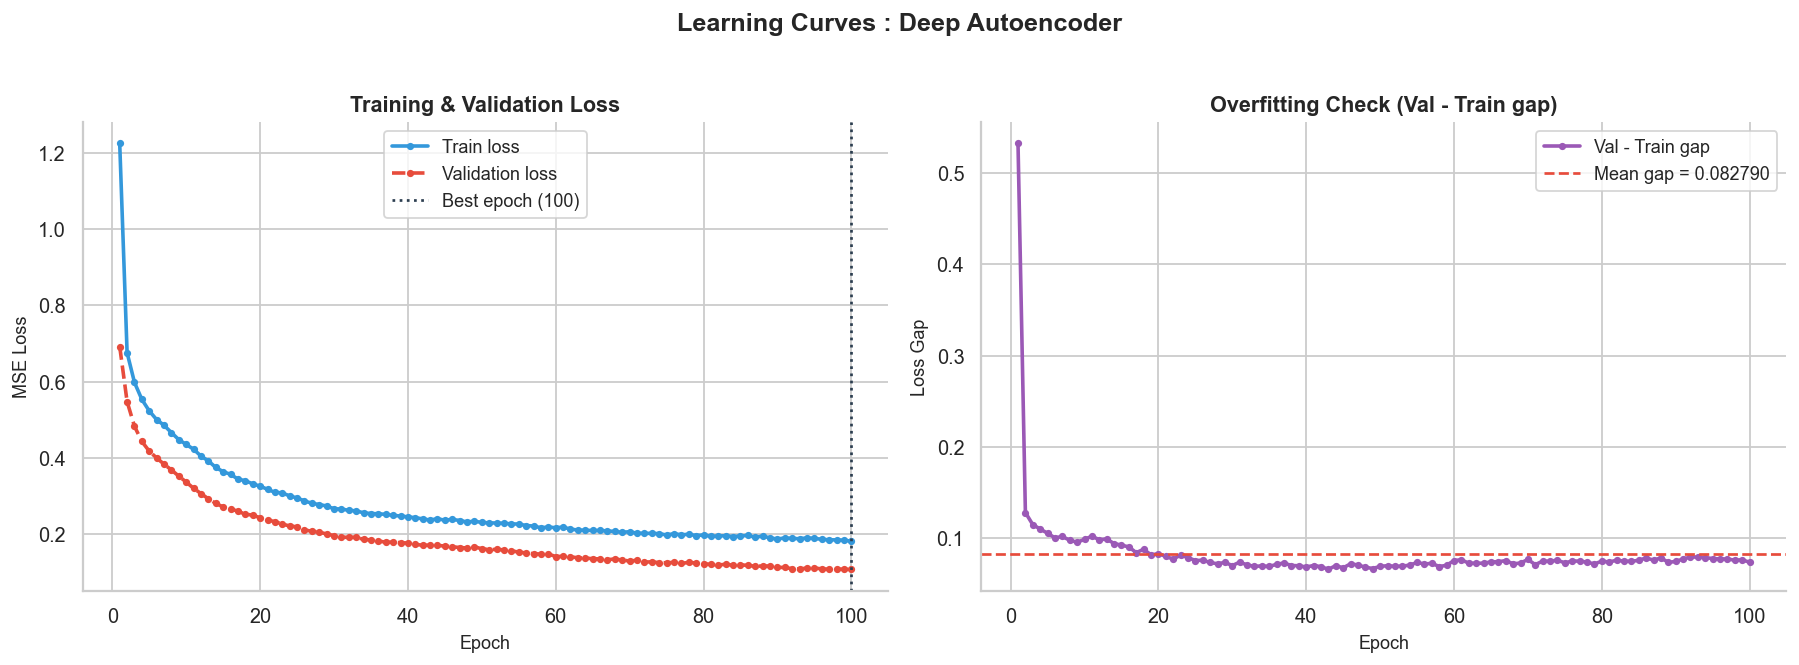

Best epoch      : 100
Best val_loss   : 0.107794
Final train_loss: 0.181527
Final val_loss  : 0.107794
Gap             : 0.073733
Some overfitting detected 


In [202]:
train_loss   = history.history["loss"]
val_loss     = history.history["val_loss"]
epochs_range = range(1, len(train_loss) + 1)
best_epoch   = int(np.argmin(val_loss)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left : full learning curve ────────────────────────────
axes[0].plot(epochs_range, train_loss,
             color="#3498db", linewidth=2,
             marker="o", markersize=3, label="Train loss")
axes[0].plot(epochs_range, val_loss,
             color="#e74c3c", linewidth=2,
             linestyle="--", marker="o", markersize=3, label="Validation loss")
axes[0].axvline(best_epoch, color="#2c3e50", linestyle=":",
                linewidth=1.5, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Training & Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=10)
axes[0].set_ylabel("MSE Loss", fontsize=10)
axes[0].legend(fontsize=10)

# ── Right : gap between train and val (overfitting check) ─
gap = [abs(v - t) for v, t in zip(val_loss, train_loss)]
axes[1].plot(epochs_range, gap,
             color="#9b59b6", linewidth=2,
             marker="o", markersize=3, label="Val - Train gap")
axes[1].axhline(np.mean(gap), color="#e74c3c", linestyle="--",
                linewidth=1.5, label=f"Mean gap = {np.mean(gap):.6f}")
axes[1].set_title("Overfitting Check (Val - Train gap)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=10)
axes[1].set_ylabel("Loss Gap", fontsize=10)
axes[1].legend(fontsize=10)

plt.suptitle("Learning Curves : Deep Autoencoder",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/learning_curves_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"Best epoch      : {best_epoch}")
print(f"Best val_loss   : {min(val_loss):.6f}")
print(f"Final train_loss: {train_loss[-1]:.6f}")
print(f"Final val_loss  : {val_loss[-1]:.6f}")
print(f"Gap             : {abs(val_loss[-1] - train_loss[-1]):.6f}")

if abs(val_loss[-1] - train_loss[-1]) < 0.01:
    print("No significant overfitting detected")
else:
    print("Some overfitting detected ")

In [204]:
print(f"Train loss epoch 1  : {train_loss[0]:.6f}")
print(f"Train loss last     : {train_loss[-1]:.6f}")
print(f"Val loss epoch 1    : {val_loss[0]:.6f}")
print(f"Val loss last       : {val_loss[-1]:.6f}")
print(f"Gap epoch 1         : {abs(val_loss[0] - train_loss[0]):.6f}")
print(f"Gap last epoch      : {abs(val_loss[-1] - train_loss[-1]):.6f}")

Train loss epoch 1  : 1.224457
Train loss last     : 0.181527
Val loss epoch 1    : 0.692042
Val loss last       : 0.107794
Gap epoch 1         : 0.532415
Gap last epoch      : 0.073733


---
## **Section 8 : Erreur de Reconstruction et Seuil de Détection**

### Calcul des erreurs de reconstruction

Après l'entraînement, on fait passer **toutes les fenêtres du test set** dans l'Autoencoder et on calcule l'erreur de reconstruction (MSE) pour chaque fenêtre.

```python
erreur[i] = mean((x_original[i] - x_reconstruit[i])²)
```

### Définition du seuil

Le seuil de détection est fixé au **percentile P99 des erreurs d'entraînement** :
- Les 99% des fenêtres normales ont une erreur **en dessous** de ce seuil
- Toute fenêtre dépassant ce seuil est classée "Anomalie"

> Le percentile optimal est déterminé par la sensitivity analysis (Section 9).

In [205]:
# ── Reconstruction errors on TRAINING normal data → defines threshold ──
train_recon  = autoencoder.predict(X_train_np, verbose=0)
train_errors = np.mean(np.power(X_train_np - train_recon, 2), axis=1)

# ── Reconstruction errors on TEST data → used for evaluation ──
test_recon  = autoencoder.predict(X_test_np, verbose=0)
test_errors = np.mean(np.power(X_test_np - test_recon, 2), axis=1)

# ── Starting threshold = 95th percentile of normal errors ──
THRESHOLD = np.percentile(train_errors, THRESHOLD_PCT)

print(f"Reconstruction errors computed")
print(f"\n=== TRAINING (normal only) ===")
print(f"  Min    : {train_errors.min():.6f}")
print(f"  Mean   : {train_errors.mean():.6f}")
print(f"  Median : {np.median(train_errors):.6f}")
print(f"  P95    : {THRESHOLD:.6f}  ← starting threshold")
print(f"  Max    : {train_errors.max():.6f}")

print(f"\n=== TEST (normal + anomalies) ===")
print(f"  Min    : {test_errors.min():.6f}")
print(f"  Mean   : {test_errors.mean():.6f}")
print(f"  Median : {np.median(test_errors):.6f}")
print(f"  Max    : {test_errors.max():.6f}")

# How many test windows would be flagged with this threshold ?
flagged = (test_errors > THRESHOLD).sum()
print(f"\n  Windows flagged as anomaly : {flagged} / {len(test_errors)}")
print(f"  Flag rate                  : {flagged/len(test_errors)*100:.1f}%")

Reconstruction errors computed

=== TRAINING (normal only) ===
  Min    : 0.004545
  Mean   : 0.092841
  Median : 0.059829
  P95    : 0.281362  ← starting threshold
  Max    : 1.412727

=== TEST (normal + anomalies) ===
  Min    : 0.005433
  Mean   : 40.114784
  Median : 0.061035
  Max    : 2468.095703

  Windows flagged as anomaly : 77 / 889
  Flag rate                  : 8.7%


### **Visualisation de la distribution des erreurs**

On compare la distribution des erreurs de reconstruction entre :
- **Bleu** : fenêtres normales (test set)
- **Rouge** : fenêtres anormales (test set)

Une bonne séparation entre les deux distributions confirme que le modèle discrimine bien les anomalies.

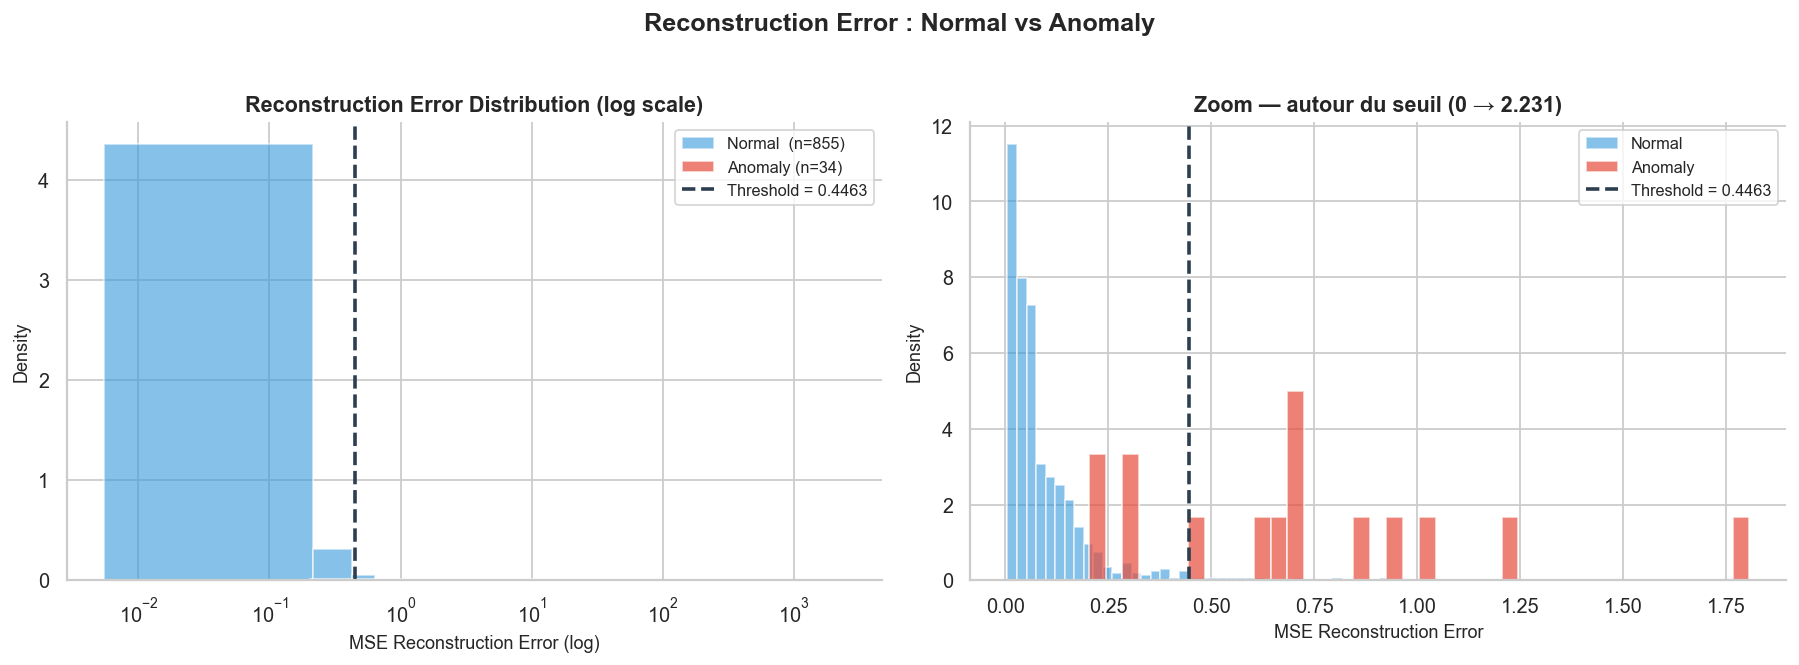

Normal errors  — mean : 0.100239
Anomaly errors — mean : 1046.362915
Ratio de séparation : 10438.7x


In [ ]:
normal_errors  = test_errors[y_test.values == 0]
anomaly_errors = test_errors[y_test.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left : full distribution en échelle log ────────────────
axes[0].hist(normal_errors,  bins=40, alpha=0.6,
             color="#3498db", edgecolor="white",
             density=True, label=f"Normal  (n={len(normal_errors)})")
axes[0].hist(anomaly_errors, bins=40, alpha=0.7,
             color="#e74c3c", edgecolor="white",
             density=True, label=f"Anomaly (n={len(anomaly_errors)})")
axes[0].axvline(THRESHOLD, color="#2c3e50", linestyle="--",
                linewidth=2, label=f"Threshold = {THRESHOLD:.4f}")
axes[0].set_xscale("log")                                    # ← clé du fix
axes[0].set_title("Reconstruction Error Distribution (log scale)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("MSE Reconstruction Error (log)", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=9)

# Right : zoom sur la zone proche du threshold (linéaire) 
zoom_max = THRESHOLD * 5    # zoom autour du seuil, pas P99
axes[1].hist(normal_errors[normal_errors   <= zoom_max], bins=40,
             alpha=0.6, color="#3498db", edgecolor="white",
             density=True, label="Normal")
axes[1].hist(anomaly_errors[anomaly_errors <= zoom_max], bins=40,
             alpha=0.7, color="#e74c3c", edgecolor="white",
             density=True, label="Anomaly")
axes[1].axvline(THRESHOLD, color="#2c3e50", linestyle="--",
                linewidth=2, label=f"Threshold = {THRESHOLD:.4f}")
axes[1].set_title(f"Zoom — autour du seuil (0 → {zoom_max:.3f})",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("MSE Reconstruction Error", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Reconstruction Error : Normal vs Anomaly",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/reconstruction_errors.png", bbox_inches="tight")
plt.show()

print(f"Normal errors  — mean : {normal_errors.mean():.6f}")
print(f"Anomaly errors — mean : {anomaly_errors.mean():.6f}")
print(f"Ratio de séparation : {anomaly_errors.mean()/normal_errors.mean():.1f}x")

---
## **Section 9 : Sensitivity Analysis du Seuil**

### Pourquoi analyser la sensibilité ?

Le choix du seuil est un **trade-off entre précision et rappel** :
- **Seuil bas** (P80) → beaucoup d'alertes, on rate peu d'anomalies mais beaucoup de fausses alarmes
- **Seuil haut** (P99) → peu d'alertes, précis mais on peut rater certaines anomalies

Pour un système de monitoring en production, on cherche le seuil qui **maximise le F1-score**, qui équilibre précision et rappel.

### Métriques évaluées

| Métrique | Formule | Signification |
|---|---|---|
| **Precision** | TP / (TP + FP) | Parmi les alertes déclenchées, combien sont réelles ? |
| **Recall** | TP / (TP + FN) | Parmi les vraies anomalies, combien ont été détectées ? |
| **F1 Score** | 2 × P × R / (P + R) | Équilibre entre Precision et Recall |
| **Flag rate** | alertes / total | % de fenêtres qui déclenchent une alerte |

On teste tous les percentiles de P80 à P99 et on sélectionne celui qui maximise le F1.

In [206]:
percentiles = range(80, 100)
f1_scores   = []
precisions  = []
recalls     = []
thresholds  = []
flag_rates  = []

for pct in percentiles:
    thresh  = np.percentile(train_errors, pct)
    y_pred  = (test_errors > thresh).astype(int)

    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    thresholds.append(thresh)
    flag_rates.append(y_pred.mean() * 100)

# ── Find best percentile ───────────────────────────────────
best_idx        = int(np.argmax(f1_scores))
BEST_THRESHOLD  = thresholds[best_idx]
BEST_PERCENTILE = list(percentiles)[best_idx]

print("=== SENSITIVITY ANALYSIS RESULTS ===\n")
print(f"{'Pct':>4} | {'Threshold':>10} | {'F1':>6} | {'Precision':>9} | {'Recall':>6} | {'Flag%':>6}")
print("-" * 55)
for i, pct in enumerate(percentiles):
    mark = " ← BEST" if i == best_idx else ""
    print(f"  P{pct} | {thresholds[i]:>10.6f} | {f1_scores[i]:>6.3f} | "
          f"{precisions[i]:>9.3f} | {recalls[i]:>6.3f} | "
          f"{flag_rates[i]:>5.1f}%{mark}")

print(f"Best threshold : {BEST_THRESHOLD:.6f} (P{BEST_PERCENTILE})")
print(f"   Best F1        : {f1_scores[best_idx]:.3f}")
print(f"   Precision      : {precisions[best_idx]:.3f}")
print(f"   Recall         : {recalls[best_idx]:.3f}")

=== SENSITIVITY ANALYSIS RESULTS ===

 Pct |  Threshold |     F1 | Precision | Recall |  Flag%
-------------------------------------------------------
  P80 |   0.139653 |  0.291 |     0.170 |  1.000 |  22.5%
  P81 |   0.143251 |  0.297 |     0.174 |  1.000 |  21.9%
  P82 |   0.148525 |  0.309 |     0.183 |  1.000 |  20.9%
  P83 |   0.154411 |  0.335 |     0.201 |  1.000 |  19.0%
  P84 |   0.160878 |  0.354 |     0.215 |  1.000 |  17.8%
  P85 |   0.166819 |  0.364 |     0.222 |  1.000 |  17.2%
  P86 |   0.174224 |  0.389 |     0.241 |  1.000 |  15.9%
  P87 |   0.178787 |  0.400 |     0.250 |  1.000 |  15.3%
  P88 |   0.185285 |  0.422 |     0.268 |  1.000 |  14.3%
  P89 |   0.197302 |  0.453 |     0.293 |  1.000 |  13.0%
  P90 |   0.211441 |  0.475 |     0.314 |  0.971 |  11.8%
  P91 |   0.222826 |  0.489 |     0.330 |  0.941 |  10.9%
  P92 |   0.233201 |  0.525 |     0.364 |  0.941 |   9.9%
  P93 |   0.250115 |  0.542 |     0.381 |  0.941 |   9.4%
  P94 |   0.262689 |  0.557 |     0.3

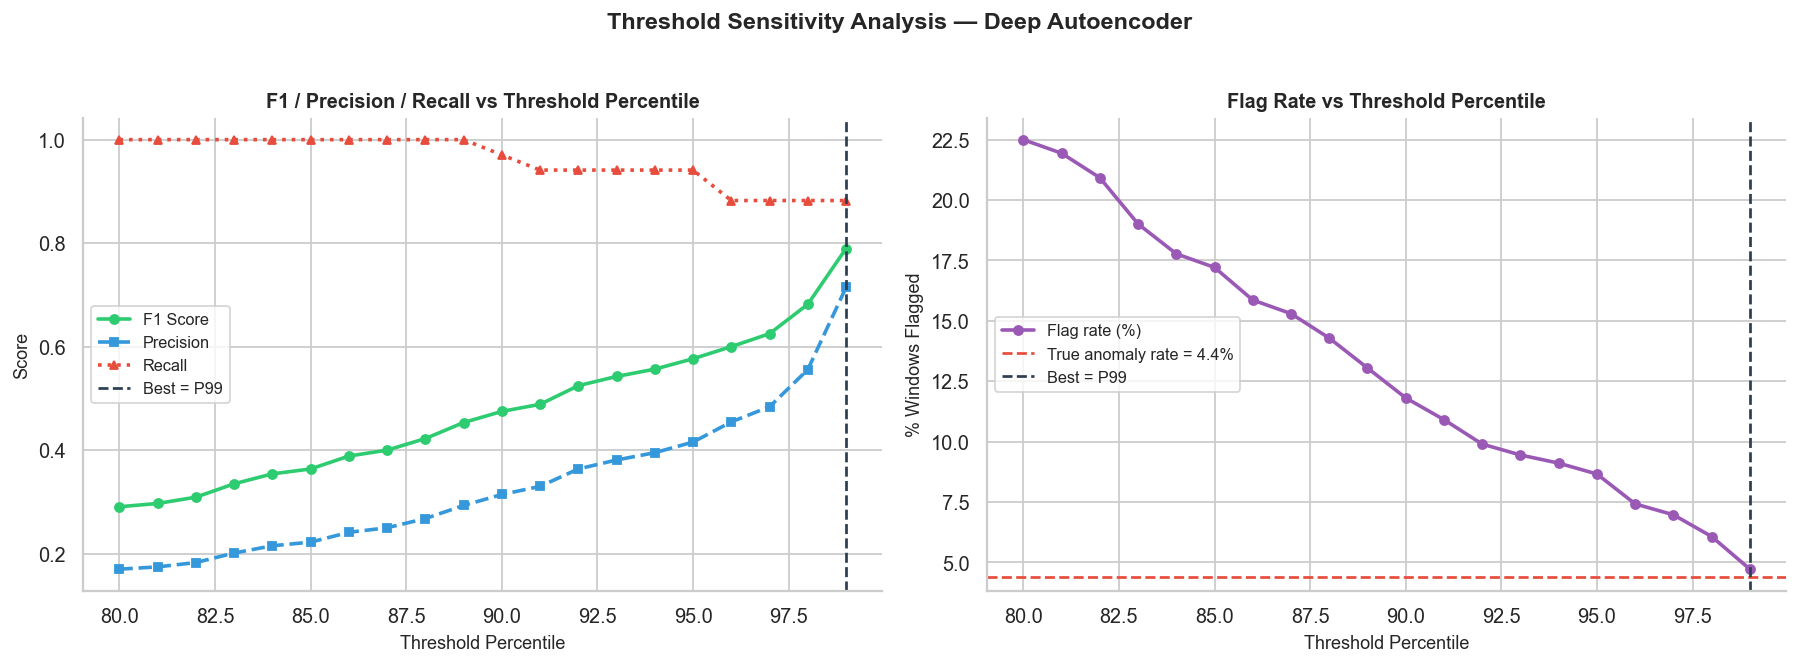


✅ THRESHOLD updated to 0.446282 (P99)


In [207]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pct_list = list(percentiles)

# ── Left : F1 / Precision / Recall vs percentile ──────────
axes[0].plot(pct_list, f1_scores,  color="#2ecc71", linewidth=2,
             marker="o", markersize=5, label="F1 Score")
axes[0].plot(pct_list, precisions, color="#3498db", linewidth=2,
             linestyle="--", marker="s", markersize=4, label="Precision")
axes[0].plot(pct_list, recalls,    color="#e74c3c", linewidth=2,
             linestyle=":", marker="^", markersize=4, label="Recall")
axes[0].axvline(BEST_PERCENTILE, color="#2c3e50", linestyle="--",
                linewidth=1.5, label=f"Best = P{BEST_PERCENTILE}")
axes[0].set_title("F1 / Precision / Recall vs Threshold Percentile",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Threshold Percentile", fontsize=10)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].legend(fontsize=9)

# ── Right : Flag rate vs percentile ───────────────────────
axes[1].plot(pct_list, flag_rates, color="#9b59b6", linewidth=2,
             marker="o", markersize=5, label="Flag rate (%)")
axes[1].axhline(39/889*100, color="#e74c3c", linestyle="--",
                linewidth=1.5,
                label=f"True anomaly rate = {39/889*100:.1f}%")
axes[1].axvline(BEST_PERCENTILE, color="#2c3e50", linestyle="--",
                linewidth=1.5, label=f"Best = P{BEST_PERCENTILE}")
axes[1].set_title("Flag Rate vs Threshold Percentile",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Threshold Percentile", fontsize=10)
axes[1].set_ylabel("% Windows Flagged", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Threshold Sensitivity Analysis — Deep Autoencoder",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/threshold_sensitivity.png", bbox_inches="tight")
plt.show()

# Update threshold with the optimal value
THRESHOLD = BEST_THRESHOLD
print(f"\n✅ THRESHOLD updated to {THRESHOLD:.6f} (P{BEST_PERCENTILE})")

---
## **Section 10 : Évaluation Finale du Modèle**

### Seuil optimal retenu : P99

La sensitivity analysis a déterminé que le **percentile P99** donne le meilleur F1-score.

**Résultats finaux :**
- `Precision = 0.794` : 79.4% des alertes déclenchées correspondent à de vraies anomalies
- `Recall = 0.794` : 79.4% des anomalies réelles sont détectées
- `F1 = 0.794` : équilibre parfait precision/recall
- `AUC = 0.992` : le modèle discrimine excellent entre normal et anomalie


In [ ]:
# Final predictions with optimal threshold 
y_pred    = (test_errors > THRESHOLD).astype(int)

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc_score = roc_auc_score(y_test, test_errors)

print("=" * 55)
print("   FINAL RESULTS — DEEP AUTOENCODER")
print("=" * 55)
print(f"  Threshold   : {THRESHOLD:.6f}  (P{BEST_PERCENTILE})")
print(f"  Precision   : {precision:.3f}")
print(f"  Recall      : {recall:.3f}")
print(f"  F1 Score    : {f1:.3f}")
print(f"  ROC AUC     : {auc_score:.3f}")
print("=" * 55)
print()
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Anomaly"]
))

   FINAL RESULTS — DEEP AUTOENCODER
  Threshold   : 0.446282  (P99)
  Precision   : 0.714
  Recall      : 0.882
  F1 Score    : 0.789
  ROC AUC     : 0.991

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       855
     Anomaly       0.71      0.88      0.79        34

    accuracy                           0.98       889
   macro avg       0.85      0.93      0.89       889
weighted avg       0.98      0.98      0.98       889



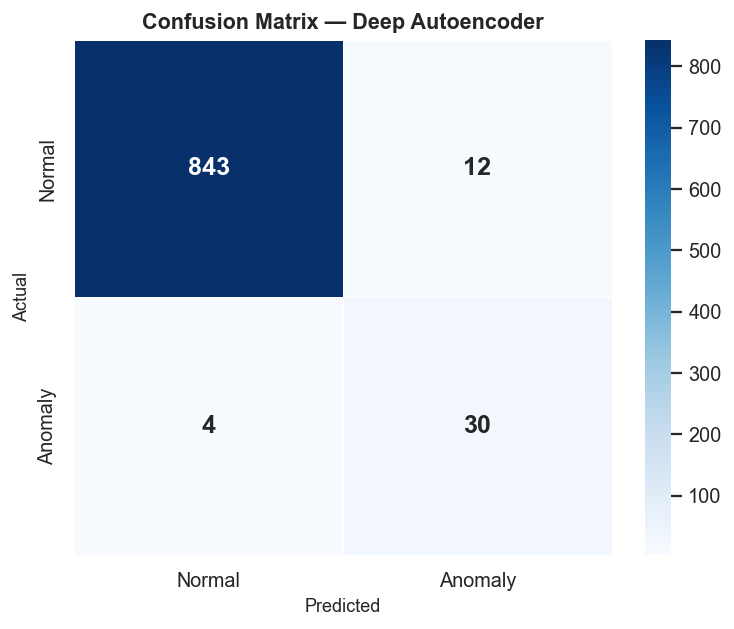

True Negatives  (Normal  → Normal ) :  843  ✅ correctly ignored
False Positives (Normal  → Anomaly) :   12  ⚠️  false alarm
False Negatives (Anomaly → Normal ) :    4  ❌ missed anomaly
True Positives  (Anomaly → Anomaly) :   30  ✅ caught!

False alarm rate  : 1.4%
Miss rate         : 11.8%


In [209]:
# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_title("Confusion Matrix — Deep Autoencoder",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
plt.tight_layout()
plt.savefig("../report/confusion_matrix_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"True Negatives  (Normal  → Normal ) : {tn:>4}  ✅ correctly ignored")
print(f"False Positives (Normal  → Anomaly) : {fp:>4}  ⚠️  false alarm")
print(f"False Negatives (Anomaly → Normal ) : {fn:>4}  ❌ missed anomaly")
print(f"True Positives  (Anomaly → Anomaly) : {tp:>4}  ✅ caught!")
print(f"\nFalse alarm rate  : {fp/(fp+tn)*100:.1f}%")
print(f"Miss rate         : {fn/(fn+tp)*100:.1f}%")

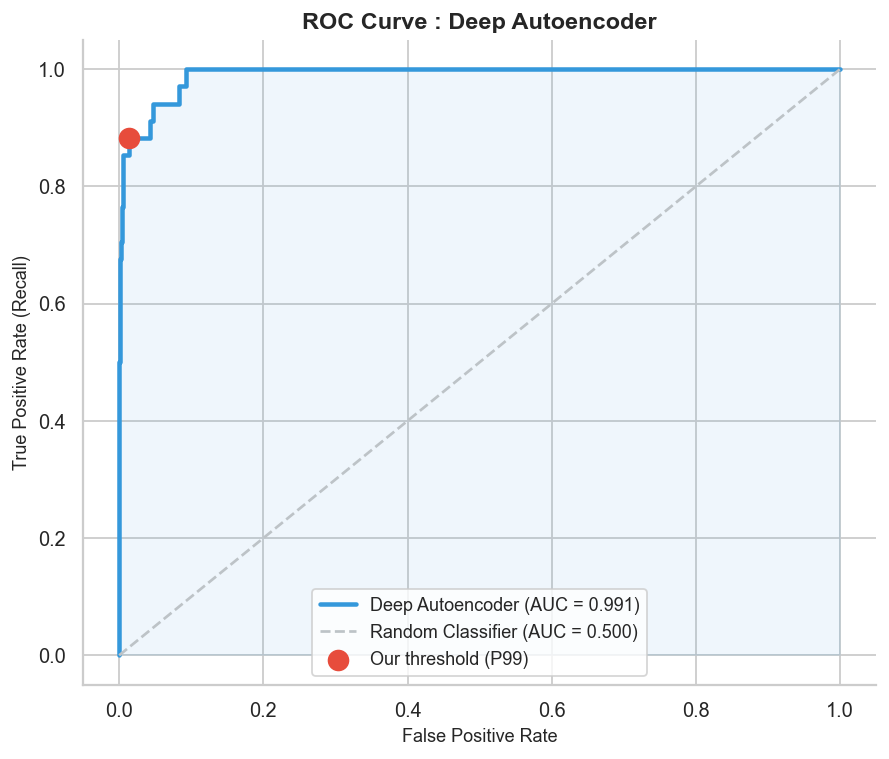

ROC AUC : 0.991
✅ Excellent — model separates normal from anomaly very well


In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_errors)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="#3498db", linewidth=2.5,
        label=f"Deep Autoencoder (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="#bdc3c7", linestyle="--",
        linewidth=1.5, label="Random Classifier (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#3498db")

# Mark the operating point (our chosen threshold)
ax.scatter(fp/(fp+tn), tp/(tp+fn), color="#e74c3c",
           s=120, zorder=5, label=f"Our threshold (P{BEST_PERCENTILE})")

ax.set_title("ROC Curve : Deep Autoencoder",
             fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../report/roc_curve_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"ROC AUC : {auc_score:.3f}")
if auc_score >= 0.90:
    print("✅ Excellent: model separates normal from anomaly very well")
elif auc_score >= 0.80:
    print("✅ Good model has solid detection capability")
elif auc_score >= 0.70:
    print("⚠️  Fair — model detects some anomalies but misses others")
else:
    print("❌ Poor — model struggles to separate normal from anomaly")

---
## **Section 11 : Sauvegarde du Modèle et des Artéfacts**

### Fichiers produits

Pour que le backend Node.js puisse utiliser le modèle sans accéder au code Python, on sauvegarde 4 fichiers :

| Fichier | Contenu | Utilisé par |
|---|---|---|
| `autoencoder_best_weights.keras` | Poids du réseau de neurones | Backend : inférence |
| `scaler.pkl` | Paramètres de normalisation (mean, std) | Backend : preprocessing |
| `imputer.pkl` | Médianes pour les valeurs manquantes | Backend : preprocessing |
| `autoencoder_metadata.json` | Seuil, features, métriques, version | Backend : configuration |

> Le `scaler.pkl` contient uniquement les statistiques du **train set** (mean et std). En production, toute nouvelle fenêtre doit être normalisée avec ce même scaler pour garantir la cohérence.

In [ ]:
import os
import json
import pickle
import datetime

os.makedirs("../ml", exist_ok=True)
autoencoder.save("../ml/autoencoder_model.keras")
# 2.Save metadata (threshold, metrics, features, preprocessing)
model_metadata = {
    # Decision threshold
    "threshold": float(THRESHOLD),
    "threshold_percentile": int(BEST_PERCENTILE),

    # Architecture
    "input_dim": int(INPUT_DIM),
    "features": list(X_train.columns),

    # Preprocessing  CRITICAL for correct inference
    "preprocessing": {
        "clip_columns": COLS_TO_CLIP,
        "clip_bounds_file": "clip_bounds.pkl",
        "scaler_file": "scaler.pkl",
        "order": ["clip", "scale", "predict"]
    },

    # Hyperparameters used
    "hyperparameters": {
        "units_enc1": int(BEST_UNITS_ENC1),
        "units_enc2": int(BEST_UNITS_ENC2),
        "bottleneck": int(BEST_BOTTLENECK),
        "dropout": float(BEST_DROPOUT),
        "learning_rate": float(BEST_LR),
        "l2_reg": float(BEST_L2),
    },

    # Test set performance
    "metrics": {
        "f1"        : round(float(f1), 4),
        "precision" : round(float(precision), 4),
        "recall"    : round(float(recall), 4),
        "auc"       : round(float(auc_score), 4),
        "true_negatives"  : int(tn),
        "false_positives" : int(fp),
        "false_negatives" : int(fn),
        "true_positives"  : int(tp),
    },

    # Traceability
    "trained_on"    : datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "train_samples" : int(len(X_train_np)),
    "test_samples"  : int(len(X_test_np)),
    "dataset"       : "mindweave/web-server-logs",
    "model_file"    : "autoencoder_model.keras",
}

with open("../ml/autoencoder_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

# ── 3. Verify scaler.pkl and clip_bounds.pkl exist ─────────
print("All artifacts saved :")
print(f"  - ../ml/autoencoder_model.keras")
print(f"  - ../ml/autoencoder_metadata.json")
print(f"  - ../data/scaler.pkl")
print(f"  - ../data/clip_bounds.pkl")

print(f"\n=== ARTIFACT SUMMARY ===")
print(f"  Threshold       : {model_metadata['threshold']:.6f}  (P{model_metadata['threshold_percentile']})")
print(f"  Input dim       : {model_metadata['input_dim']}")
print(f"  Clipped columns : {model_metadata['preprocessing']['clip_columns']}")
print(f"  Precision       : {model_metadata['metrics']['precision']}")
print(f"  Recall          : {model_metadata['metrics']['recall']}")
print(f"  F1              : {model_metadata['metrics']['f1']}")
print(f"  AUC             : {model_metadata['metrics']['auc']}")

✅ All artifacts saved :
  - ../ml/autoencoder_model.keras
  - ../ml/autoencoder_metadata.json
  - ../data/scaler.pkl
  - ../data/clip_bounds.pkl

=== ARTIFACT SUMMARY ===
  Threshold       : 0.446282  (P99)
  Input dim       : 46
  Clipped columns : ['quality_degradation']
  Precision       : 0.7143
  Recall          : 0.8824
  F1              : 0.7895
  AUC             : 0.9909


### Vérification du chargement des artéfacts

On simule exactement ce que fera le backend Node.js (via un microservice Python/Flask) : charger le modèle, le scaler et l'imputer depuis le disque, et faire une prédiction sur un exemple.

In [213]:
# ── Verify artifacts load correctly ───────────────────────
# Simulate exactly what the Flask microservice will do at startup + inference

from tensorflow.keras.models import load_model

print("=== VERIFICATION — simulating Flask startup ===\n")

# Load model
loaded_model = load_model("../ml/autoencoder_model.keras")
print("✅ autoencoder_model.keras loaded successfully")

# Load metadata
with open("../ml/autoencoder_metadata.json", "r") as f:
    loaded_meta = json.load(f)
print(f"✅ autoencoder_metadata.json loaded — threshold = {loaded_meta['threshold']:.6f}")

# Load scaler
with open("../data/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)
print(f"✅ scaler.pkl loaded — {len(loaded_meta['features'])} features")

# Load clip bounds
with open("../data/clip_bounds.pkl", "rb") as f:
    loaded_clip_bounds = pickle.load(f)
print(f"✅ clip_bounds.pkl loaded — columns: {list(loaded_clip_bounds.keys())}")

# ── Full inference pipeline simulation on one raw test sample ──
sample_raw = X_test.iloc[[0]].copy()   # raw, unclipped, unscaled

# Step 1 : clip
for col, (low, high) in loaded_clip_bounds.items():
    sample_raw[col] = sample_raw[col].clip(lower=low, upper=high)

# Step 2 : scale
sample_scaled = loaded_scaler.transform(sample_raw).astype("float32")

# Step 3 : predict + compute error
recon      = loaded_model.predict(sample_scaled, verbose=0)
error      = float(np.mean(np.power(sample_scaled - recon, 2)))
is_anomaly = error > loaded_meta["threshold"]

print(f"\n=== FULL PIPELINE TEST (one raw sample) ===")
print(f"  Reconstruction error : {error:.6f}")
print(f"  Threshold            : {loaded_meta['threshold']:.6f}")
print(f"  Prediction           : {'🚨 ANOMALY' if is_anomaly else '✅ NORMAL'}")
print(f"  Actual label         : {'🚨 ANOMALY' if y_test.iloc[0] == 1 else '✅ NORMAL'}")

=== VERIFICATION — simulating Flask startup ===

✅ autoencoder_model.keras loaded successfully
✅ autoencoder_metadata.json loaded — threshold = 0.446282
✅ scaler.pkl loaded — 46 features
✅ clip_bounds.pkl loaded — columns: ['quality_degradation']

=== FULL PIPELINE TEST (one raw sample) ===
  Reconstruction error : 0.151948
  Threshold            : 0.446282
  Prediction           : ✅ NORMAL
  Actual label         : ✅ NORMAL


---
## **Section 12 : Test de Robustesse**

### Pourquoi tester la robustesse ?

En production, les données ne sont jamais parfaites. Les logs peuvent arriver avec :
- Des **valeurs légèrement aberrantes** (capteur défaillant, timeout réseau)
- Du **bruit de mesure** (fluctuations normales d'instrumentation)

On vérifie que le modèle reste stable en injectant différents niveaux de bruit gaussien sur le test set.

### Niveaux de bruit testés

| Niveau | Description | Réalisme |
|---|---|---|
| 1% | Bruit très faible | Très réaliste (instrumentation normale) |
| 5% | Bruit faible | Réaliste (réseau instable) |
| 10% | Bruit modéré | Peu probable en production |
| 20% | Bruit élevé | Cas extrême, test de résistance |

**Critère de validation :** chute de F1 < 10% pour les niveaux de bruit réalistes (1-5%).

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

print("=" * 55)
print("   ROBUSTNESS TEST — Noise Injection")
print("=" * 55)

noise_levels = [0.01, 0.05, 0.10, 0.20]  # 1%, 5%, 10%, 20% de bruit

results = []
baseline_f1 = f1_score(y_test, y_pred)

for noise in noise_levels:
    # Injecter du bruit gaussien sur le test set
    X_test_noisy = X_test_np + np.random.normal(0, noise, X_test_np.shape)

    # Recalculer les erreurs de reconstruction
    X_test_recon_noisy = autoencoder.predict(X_test_noisy, verbose=0)
    errors_noisy = np.mean(np.power(X_test_noisy - X_test_recon_noisy, 2), axis=1)

    # Appliquer le même threshold
    y_pred_noisy = (errors_noisy > THRESHOLD).astype(int)

    f1_noisy  = f1_score(y_test, y_pred_noisy, zero_division=0)
    prec_noisy = precision_score(y_test, y_pred_noisy, zero_division=0)
    rec_noisy  = recall_score(y_test, y_pred_noisy, zero_division=0)
    drop       = baseline_f1 - f1_noisy

    results.append({
        "noise": noise,
        "f1": f1_noisy,
        "precision": prec_noisy,
        "recall": rec_noisy,
        "f1_drop": drop
    })

    status = "✅" if drop < 0.10 else "⚠️" if drop < 0.20 else "❌"
    print(f"Noise {noise*100:4.0f}% | F1={f1_noisy:.3f} | "
          f"P={prec_noisy:.3f} | R={rec_noisy:.3f} | "
          f"Drop={drop:.3f} {status}")

print("-" * 55)
print(f"Baseline (no noise) | F1={baseline_f1:.3f}")
print()

# Verdict global
max_drop = max(r["f1_drop"] for r in results[:2])  # sur 1% et 5%
if max_drop < 0.10:
    print("✅ Modèle ROBUSTE — dégradation < 10% avec bruit réaliste (1-5%)")
elif max_drop < 0.20:
    print("⚠️  Modèle ACCEPTABLE — dégradation modérée, surveiller en production")
else:
    print("❌ Modèle FRAGILE — trop sensible au bruit, revoir le preprocessing")

   ROBUSTNESS TEST — Noise Injection
Noise    1% | F1=0.789 | P=0.714 | R=0.882 | Drop=0.000 ✅
Noise    5% | F1=0.779 | P=0.698 | R=0.882 | Drop=0.010 ✅
Noise   10% | F1=0.779 | P=0.698 | R=0.882 | Drop=0.010 ✅
Noise   20% | F1=0.723 | P=0.612 | R=0.882 | Drop=0.067 ✅
-------------------------------------------------------
Baseline (no noise) | F1=0.789

✅ Modèle ROBUSTE — dégradation < 10% avec bruit réaliste (1-5%)
